# Align the conditioned backbone with reward function

## Step 1: Find the residual vector field by solving a PDE using PINN

In [2]:
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import model as _m; importlib.reload(_m)
import flow as _f; importlib.reload(_f)
import data as _d; importlib.reload(_d)

from model import ConditionalMLPVelocity, PINN, Reward2D
from flow import sample_trajectory
from data import SwissrollWithLabel, sample_noise

In [3]:
device = "cpu"
NUM_CLASSES = SwissrollWithLabel.NUM_CLASSES

# ---- Frozen base model (conditioned backbone) ----
v_base = ConditionalMLPVelocity(cond_dim=4, num_classes=NUM_CLASSES, dropout_prob=0.1)
v_base.load_state_dict(torch.load("conditioned_backbone.pt", map_location=device))
v_base.eval()
for p in v_base.parameters():
    p.requires_grad_(False)

# ---- Reward function (no trainable params) ----
reward_fn = Reward2D(num_classes=NUM_CLASSES)

# ---- PINN value network ----
pinn = PINN(cond_dim=4, num_classes=NUM_CLASSES)
lam = 1.0

print(f"PINN parameters: {sum(p.numel() for p in pinn.parameters()):,}")

PINN parameters: 83,615


In [4]:
eps = 1e-3
e1 = torch.tensor([[eps, 0.0]], device=device)
e2 = torch.tensor([[0.0, eps]], device=device)
dt_eps = torch.tensor([[eps]], device=device)
log_every = 500
history = {"loss": [], "pde": [], "bdy": [], "con": []}

# =====================================================================
# Phase 1 — Boundary warmup (w-head learns w(x,1,c) ≈ −∇r)
#   No PDE, no consistency: avoids competing gradients that pin w ≈ 0.
#   Higher lr lets Adam overcome the stochastic noise of the target.
# =====================================================================
warmup_epochs = 3000
warmup_bs = 1024
opt_warmup = torch.optim.Adam(pinn.parameters(), lr=1e-2)
sched_warmup = torch.optim.lr_scheduler.CosineAnnealingLR(opt_warmup, warmup_epochs, eta_min=1e-3)

pinn.train()
for epoch in range(1, warmup_epochs + 1):
    xb = torch.randn(warmup_bs, 2, device=device)
    cb = torch.randint(0, NUM_CLASSES, (warmup_bs,), device=device)
    tb = torch.ones(warmup_bs, 1, device=device)

    wb = pinn(xb, tb, cb)

    xb_g = xb.detach().requires_grad_(True)
    r = reward_fn(xb_g, cb)
    dr_dx = torch.autograd.grad(r.sum(), xb_g)[0].detach()

    loss_bdy = ((wb + dr_dx) ** 2).sum(dim=1).mean()

    opt_warmup.zero_grad()
    loss_bdy.backward()
    opt_warmup.step()
    sched_warmup.step()

    history["loss"].append(loss_bdy.item())
    history["pde"].append(0.0)
    history["bdy"].append(loss_bdy.item())
    history["con"].append(0.0)

    if epoch % log_every == 0:
        print(f"[Warmup {epoch}/{warmup_epochs}]  bdy={loss_bdy.item():.4e}  lr={opt_warmup.param_groups[0]['lr']:.2e}")

# =====================================================================
# Phase 2 — Full PINN training (PDE + boundary + consistency)
# =====================================================================
pde_epochs = 5000
batch_size = 512
alpha_bdy = 5.0
alpha_con = 0.5
opt_pde = torch.optim.Adam(pinn.parameters(), lr=1e-3)
sched_pde = torch.optim.lr_scheduler.CosineAnnealingLR(opt_pde, pde_epochs, eta_min=1e-5)

for epoch in range(1, pde_epochs + 1):
    x = torch.randn(batch_size, 2, device=device)
    t = torch.rand(batch_size, 1, device=device).clamp(eps, 1.0 - eps)
    c = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)

    V0, w0 = pinn.forward_all(x, t, c)

    Vtp = pinn.potential(x, t + dt_eps, c)
    Vtm = pinn.potential(x, t - dt_eps, c)
    dV_dt = (Vtp - Vtm) / (2 * eps)

    Vxp1 = pinn.potential(x + e1, t, c)
    Vxm1 = pinn.potential(x - e1, t, c)
    Vxp2 = pinn.potential(x + e2, t, c)
    Vxm2 = pinn.potential(x - e2, t, c)
    fd_grad = torch.cat([(Vxp1 - Vxm1), (Vxp2 - Vxm2)], dim=1) / (2 * eps)

    with torch.no_grad():
        v = v_base(x, t, c)

    grad_sq = (w0 ** 2).sum(dim=1, keepdim=True)
    dot_val = (w0 * v).sum(dim=1, keepdim=True)
    residual = dV_dt - grad_sq / (2 * lam) + dot_val
    loss_pde = (residual ** 2).mean()

    loss_con = ((w0 - fd_grad) ** 2).sum(dim=1).mean()

    xb = torch.randn(batch_size, 2, device=device)
    cb = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
    tb = torch.ones(batch_size, 1, device=device)
    wb = pinn(xb, tb, cb)
    xb_g = xb.detach().requires_grad_(True)
    rb = reward_fn(xb_g, cb)
    dr_dx = torch.autograd.grad(rb.sum(), xb_g)[0].detach()
    loss_bdy = ((wb + dr_dx) ** 2).sum(dim=1).mean()

    loss = loss_pde + alpha_bdy * loss_bdy + alpha_con * loss_con

    opt_pde.zero_grad()
    loss.backward()
    opt_pde.step()
    sched_pde.step()

    history["loss"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["bdy"].append(loss_bdy.item())
    history["con"].append(loss_con.item())

    if epoch % log_every == 0:
        print(
            f"[PDE {epoch}/{pde_epochs}]  loss={loss.item():.4e}  "
            f"pde={loss_pde.item():.4e}  bdy={loss_bdy.item():.4e}  "
            f"con={loss_con.item():.4e}"
        )

# ---- Diagnostic ----
pinn.eval()
with torch.no_grad():
    x_test = torch.randn(512, 2, device=device)
    t_test = torch.ones(512, 1, device=device)
    c_test = torch.randint(0, NUM_CLASSES, (512,), device=device)
    w_test = pinn(x_test, t_test, c_test)
    v_b = v_base(x_test, t_test, c_test)
    ratio = w_test.norm(dim=1).mean() / v_b.norm(dim=1).mean()
    print(f"\n||w|| at t=1:   mean={w_test.norm(dim=1).mean():.4f}, max={w_test.norm(dim=1).max():.4f}")
    print(f"||v_base||:     mean={v_b.norm(dim=1).mean():.4f}")
    print(f"Correction ratio: {ratio:.4f}")

[Warmup 500/3000]  bdy=2.6517e-01  lr=9.40e-03
[Warmup 1000/3000]  bdy=5.5823e-02  lr=7.75e-03
[Warmup 1500/3000]  bdy=2.7910e-02  lr=5.50e-03
[Warmup 2000/3000]  bdy=1.9354e-02  lr=3.25e-03
[Warmup 2500/3000]  bdy=4.0163e-02  lr=1.60e-03
[Warmup 3000/3000]  bdy=1.0866e-02  lr=1.00e-03
[PDE 500/5000]  loss=2.0728e+01  pde=8.3594e+00  bdy=2.2814e+00  con=1.9221e+00
[PDE 1000/5000]  loss=1.2322e+01  pde=5.4085e+00  bdy=1.2558e+00  con=1.2685e+00
[PDE 1500/5000]  loss=6.4155e+00  pde=2.4636e+00  bdy=7.0887e-01  con=8.1498e-01
[PDE 2000/5000]  loss=6.3402e+00  pde=3.3785e+00  bdy=4.2557e-01  con=1.6676e+00
[PDE 2500/5000]  loss=4.2234e+00  pde=2.2549e+00  bdy=2.3725e-01  con=1.5646e+00
[PDE 3000/5000]  loss=3.0706e+00  pde=1.1028e+00  bdy=2.3755e-01  con=1.5601e+00
[PDE 3500/5000]  loss=2.3716e+00  pde=1.0702e+00  bdy=1.7597e-01  con=8.4309e-01
[PDE 4000/5000]  loss=2.4185e+00  pde=1.1707e+00  bdy=1.7892e-01  con=7.0647e-01
[PDE 4500/5000]  loss=2.2460e+00  pde=8.7062e-01  bdy=1.7793e-01  

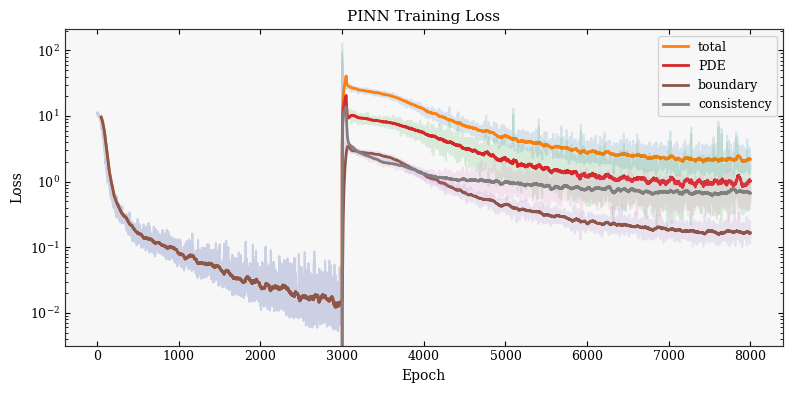

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 50
for key, label in [("loss", "total"), ("pde", "PDE"), ("bdy", "boundary"), ("con", "consistency")]:
    raw = history[key]
    ax.plot(raw, alpha=0.15)
    smoothed = np.convolve(raw, np.ones(w) / w, mode="valid")
    ax.plot(range(w - 1, len(raw)), smoothed, linewidth=2, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.set_title("PINN Training Loss")
plt.tight_layout()
plt.show()

## Step 2: Aligned sampling — $v_{\text{aligned}} = v_{\text{base}} + \nabla_x V_\phi$

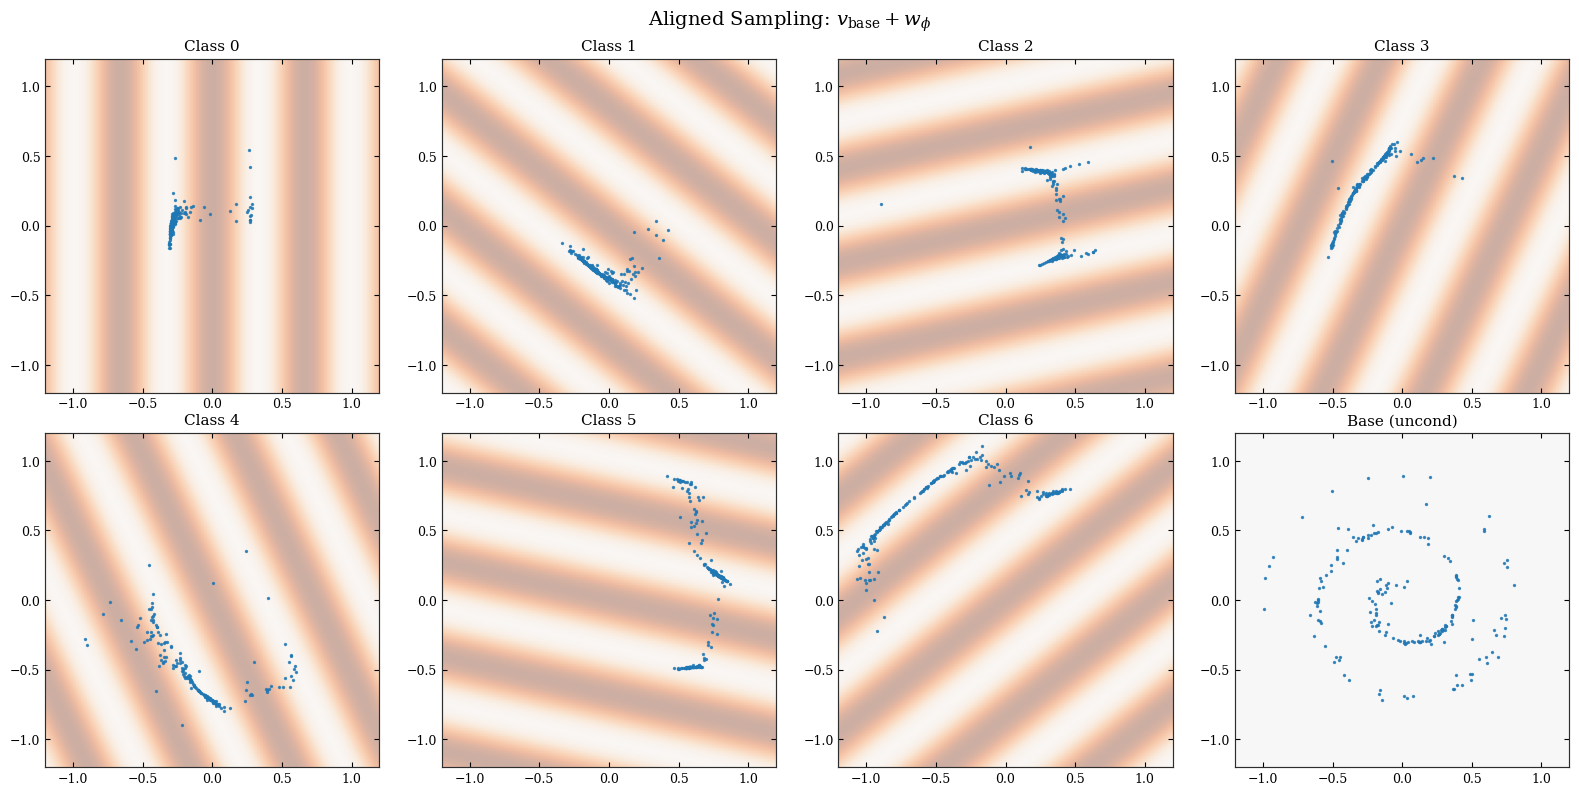

In [6]:
pinn.eval()
n_per_class = 200
grid_n = 120
extent = [-1.2, 1.2, -1.2, 1.2]

xs_grid = torch.linspace(-1.2, 1.2, grid_n)
ys_grid = torch.linspace(-1.2, 1.2, grid_n)
Xg, Yg = torch.meshgrid(xs_grid, ys_grid, indexing="xy")
grid_pts = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for label in range(NUM_CLASSES + 1):
    ax = axes[label // 4, label % 4]
    x0 = sample_noise(n_per_class, device=device, seed=label)

    if label < NUM_CLASSES:
        label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)
        traj = sample_trajectory(
            x0,
            lambda x, t, c=label_t: v_base(x, t, c) + pinn(x, t, c),
            n_steps=80,
        )
        title = f"Class {label}"

        with torch.no_grad():
            y_grid = torch.full((grid_pts.size(0),), label, dtype=torch.long)
            R = reward_fn(grid_pts, y_grid).reshape(grid_n, grid_n).numpy()
        ax.imshow(
            R, origin="lower", extent=extent, aspect="equal",
            cmap="Oranges", alpha=0.35, vmin=0, vmax=1,
        )
    else:
        uncond = torch.full((n_per_class,), NUM_CLASSES, dtype=torch.long, device=device)
        traj = sample_trajectory(
            x0,
            lambda x, t, c=uncond: v_base(x, t, c),
            n_steps=80,
        )
        title = "Base (uncond)"

    x1 = traj["xs"][-1].cpu().numpy()
    ax.scatter(x1[:, 0], x1[:, 1], marker=".", s=8, alpha=0.8, zorder=2)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

plt.suptitle(r"Aligned Sampling: $v_{\mathrm{base}} + w_\phi$", fontsize=14)
plt.tight_layout()
plt.show()

## Animation (8 panels)

Three GIFs matching the fine-tuning layout: **(1)** aligned velocity $\mathbf{v}_{\mathrm{aligned}} = \mathbf{v}_{\mathrm{base}} + \mathbf{w}_\phi$ (jet + global log colorbar); **(2)** base field in **Greys** and residual $\mathbf{w}_\phi$ in **Reds** (two quiver layers); **(3)** residual only (Reds). Class-conditioned panels use alignment; the unconditional panel uses $\mathbf{v}_{\mathrm{base}}$ only and zero residual, matching the static figure. Run PINN training above first. Optional: save `torch.save(pinn.state_dict(), "alignment_pinn.pt")` to reload later.


In [8]:
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm

from model import ConditionalMLPVelocity, PINN, Reward2D
from data import SwissrollWithLabel, sample_noise
from flow import sample_trajectory

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Times", "serif"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f8",
        "axes.edgecolor": "#2d2d2d",
        "axes.linewidth": 0.85,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

device = torch.device("cpu")

try:
    _vb = v_base
except NameError:
    _vb = ConditionalMLPVelocity(
        cond_dim=4, num_classes=SwissrollWithLabel.NUM_CLASSES, dropout_prob=0.1
    ).to(device)
    _vb.load_state_dict(
        torch.load("conditioned_backbone.pt", map_location=device, weights_only=True)
    )
_vb.eval()
for p in _vb.parameters():
    p.requires_grad_(False)

try:
    _pn = pinn
except NameError:
    _pn = PINN(cond_dim=4, num_classes=SwissrollWithLabel.NUM_CLASSES).to(device)
    ckpt = "alignment_pinn.pt"
    if not os.path.isfile(ckpt):
        raise RuntimeError(
            "Define `pinn` by running training cells, or save weights to alignment_pinn.pt"
        )
    _pn.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
_pn.eval()

num_classes = SwissrollWithLabel.NUM_CLASSES
n_panels = num_classes + 1
n_steps = 80
n_per_class = 160
lim = 1.2
ng = 13
pause_frames = 36

# --- particle trajectories (same rule as static figure) ---
trajectories = []
for label in range(n_panels):
    x0 = sample_noise(n_per_class, device=device, seed=label)
    label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)

    if label < num_classes:

        def v_fn(x, t, c=label_t):
            return _vb(x, t, c) + _pn(x, t, c)

    else:

        def v_fn(x, t, c=label_t):
            return _vb(x, t, c)

    with torch.no_grad():
        traj = sample_trajectory(x0, v_fn, n_steps=n_steps)
    trajectories.append(traj["xs"].cpu().numpy())

times = np.linspace(0.0, 1.0, n_steps + 1)

gx = np.linspace(-lim, lim, ng)
gy = np.linspace(-lim, lim, ng)
GX, GY = np.meshgrid(gx, gy, indexing="xy")
grid_np = np.stack([GX.ravel(), GY.ravel()], axis=1).astype(np.float32)
grid_t = torch.from_numpy(grid_np).to(device)

# --- precompute base / residual / total on grid ---
all_spd_b = []
all_spd_r = []
all_spd_t = []
panel_UVB = []
panel_UVR = []
panel_UVT = []

for label in range(n_panels):
    lbl = torch.full((grid_t.shape[0],), label, dtype=torch.long, device=device)
    Ub, Vb, Sb = [], [], []
    Ur, Vr, Sr = [], [], []
    Ut, Vt, St = [], [], []

    for k in range(n_steps + 1):
        tk = float(times[k])
        tt = torch.full((grid_t.shape[0], 1), tk, device=device, dtype=torch.float32)
        with torch.no_grad():
            vb = _vb(grid_t, tt, lbl).cpu().numpy()
            # PINN.embedding is only 0..num_classes-1; unconditional label == NUM_CLASSES is invalid
            if label < num_classes:
                wr = _pn(grid_t, tt, lbl).cpu().numpy()
            else:
                wr = np.zeros_like(vb)

        Ub_ = vb[:, 0].reshape(ng, ng)
        Vb_ = vb[:, 1].reshape(ng, ng)
        sb = np.hypot(Ub_, Vb_)

        Wr_ = wr[:, 0].reshape(ng, ng)
        Wr2 = wr[:, 1].reshape(ng, ng)
        sr = np.hypot(Wr_, Wr2)

        if label < num_classes:
            Ut_ = Ub_ + Wr_
            Vt_ = Vb_ + Wr2
        else:
            Wr_ = np.zeros_like(Ub_)
            Wr2 = np.zeros_like(Vb_)
            sr = np.zeros_like(sb)
            Ut_ = Ub_
            Vt_ = Vb_

        st = np.hypot(Ut_, Vt_)

        Ub.append(Ub_)
        Vb.append(Vb_)
        Sb.append(sb)
        Ur.append(Wr_)
        Vr.append(Wr2)
        Sr.append(sr)
        Ut.append(Ut_)
        Vt.append(Vt_)
        St.append(st)

        all_spd_b.append(sb.ravel())
        all_spd_r.append(sr.ravel())
        all_spd_t.append(st.ravel())

    panel_UVB.append((Ub, Vb, Sb))
    panel_UVR.append((Ur, Vr, Sr))
    panel_UVT.append((Ut, Vt, St))


def _log_limits(spd_flat: np.ndarray) -> tuple[float, float]:
    spd_pos = spd_flat[spd_flat > 0]
    if spd_pos.size == 0:
        return 1e-4, 1.0
    v_lo = float(np.percentile(spd_pos, 2))
    v_hi = float(np.percentile(spd_pos, 99.8))
    v_lo = max(v_lo, 1e-5)
    if v_hi <= v_lo * 1.01:
        v_hi = v_lo * 10.0
    return v_lo, v_hi


v_lo_t, v_hi_t = _log_limits(np.concatenate(all_spd_t))
v_lo_b, v_hi_b = _log_limits(np.concatenate(all_spd_b))
# residual: ignore exact zeros for scale (uncond panel)
v_lo_r, v_hi_r = _log_limits(np.concatenate(all_spd_r))

norm_t = LogNorm(vmin=v_lo_t, vmax=v_hi_t)
norm_b = LogNorm(vmin=v_lo_b, vmax=v_hi_b)
norm_r = LogNorm(vmin=v_lo_r, vmax=v_hi_r)

# Reward heatmap (Reward2D depends on x and class only, not t; no map for uncond)
reward_ng = 160
rx = np.linspace(-lim, lim, reward_ng)
ry = np.linspace(-lim, lim, reward_ng)
RXr, RYr = np.meshgrid(rx, ry, indexing="xy")
grid_reward_np = np.stack([RXr.ravel(), RYr.ravel()], axis=1).astype(np.float32)
grid_reward = torch.from_numpy(grid_reward_np).to(device)
_reward_heat = Reward2D(num_classes=num_classes).to(device).eval()
reward_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "reward_smooth",
    ["#f4f4f6", "#fff2e6", "#ffd4b8", "#ffb088", "#f07850", "#c84838"],
)
panel_reward_R = []
with torch.no_grad():
    for p in range(n_panels):
        if p < num_classes:
            y_lbl = torch.full(
                (grid_reward.shape[0],), p, dtype=torch.long, device=device
            )
            Rp = _reward_heat(grid_reward, y_lbl).reshape(
                reward_ng, reward_ng
            ).cpu().numpy()
            panel_reward_R.append(Rp)
        else:
            panel_reward_R.append(None)

cell = (2 * lim) / max(ng - 1, 1)
arrow_len = 0.40 * cell


def _quiver_update(Q, U, Vv, spd, norm, v_lo, v_hi):
    mag = np.hypot(U, Vv)
    U_n = U / (mag + 1e-9)
    V_n = Vv / (mag + 1e-9)
    spd_c = np.maximum(np.clip(spd, v_lo, v_hi), v_lo)
    Q.set_norm(norm)
    Q.set_UVC(U_n * arrow_len, V_n * arrow_len, spd_c)


def run_total_jet(out_path: str) -> None:
    try:
        cmap = mpl.colormaps["jet"]
    except (AttributeError, KeyError):
        cmap = mpl.cm.get_cmap("jet")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8.2), dpi=120)
    plt.subplots_adjust(
        left=0.06, right=0.93, top=0.90, bottom=0.07, wspace=0.22, hspace=0.30
    )
    axes_flat = axes.ravel()

    Qs = []
    scats = []
    for p, ax in enumerate(axes_flat):
        Rimg = panel_reward_R[p]
        if Rimg is not None:
            ax.pcolormesh(
                RXr,
                RYr,
                Rimg,
                shading="gouraud",
                cmap=reward_cmap,
                vmin=0.0,
                vmax=1.0,
                alpha=0.22,
                zorder=1,
                antialiased=True,
            )
        Q = ax.quiver(
            GX,
            GY,
            np.zeros_like(GX),
            np.zeros_like(GY),
            np.zeros_like(GX),
            cmap=cmap,
            norm=norm_t,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.0018,
            headwidth=3.0,
            headlength=3.8,
            headaxislength=3.0,
            zorder=2,
            alpha=0.58,
        )
        scat = ax.scatter(
            trajectories[p][0, :, 0],
            trajectories[p][0, :, 1],
            s=5,
            c="#16213e",
            alpha=0.78,
            linewidths=0,
            zorder=4,
        )
        Qs.append(Q)
        scats.append(scat)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, color="#b8b8c0", linewidth=0.45, linestyle="--", alpha=0.75)
        ax.set_axisbelow(True)
        ax.set_title(f"Class {p}" if p < num_classes else "Unconditional", fontsize=11)

    cbar = fig.colorbar(Qs[0], ax=list(axes_flat), fraction=0.022, pad=0.02)
    cbar.set_label(
        r"$\|\mathbf{{v}}_{{\mathrm{{base}}}}+\tilde{{\mathbf{{v}}}}_{{\theta}}\|$ (log scale)", rotation=270, labelpad=16
    )

    def _frame(i: int):
        i = int(i)
        k = n_steps if i > n_steps else i
        t = float(times[k])
        for p in range(n_panels):
            scats[p].set_offsets(trajectories[p][k])
            Ut, Vt, St = panel_UVT[p][0][k], panel_UVT[p][1][k], panel_UVT[p][2][k]
            _quiver_update(Qs[p], Ut, Vt, St, norm_t, v_lo_t, v_hi_t)

        if k == n_steps and i > n_steps:
            st = r"Aligned vector field $\mathbf{{v}}_{{\mathrm{{base}}}}+\tilde{{\mathbf{{v}}}}_{{\theta}}$: $t=1.000$ (hold)"
        else:
            st = rf"Aligned vector field $\mathbf{{v}}_{{\mathrm{{base}}}}+\tilde{{\mathbf{{v}}}}_{{\theta}}$: $t={t:.3f}$"
        fig.suptitle(st, fontsize=12, y=0.995)

    anim = FuncAnimation(
        fig, _frame, frames=n_steps + 1 + pause_frames, interval=55, blit=False
    )
    anim.save(out_path, writer=PillowWriter(fps=18), dpi=110)
    plt.close(fig)
    print(f"Saved: {out_path}")


def run_base_gray_residual_red(out_path: str) -> None:
    try:
        cmap_b = mpl.colormaps["Greys"]
        cmap_r = mpl.colormaps["Reds"]
    except (AttributeError, KeyError):
        cmap_b = mpl.cm.get_cmap("Greys")
        cmap_r = mpl.cm.get_cmap("Reds")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8.2), dpi=120)
    plt.subplots_adjust(
        left=0.06, right=0.93, top=0.90, bottom=0.07, wspace=0.22, hspace=0.30
    )
    axes_flat = axes.ravel()

    Qbs, Qrs, scats = [], [], []
    for p, ax in enumerate(axes_flat):
        Qb = ax.quiver(
            GX,
            GY,
            np.zeros_like(GX),
            np.zeros_like(GY),
            np.zeros_like(GX),
            cmap=cmap_b,
            norm=norm_b,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.0016,
            headwidth=3.0,
            headlength=3.8,
            headaxislength=3.0,
            zorder=2,
            alpha=0.72,
        )
        Qr = ax.quiver(
            GX,
            GY,
            np.zeros_like(GX),
            np.zeros_like(GY),
            np.zeros_like(GX),
            cmap=cmap_r,
            norm=norm_r,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.0018,
            headwidth=3.0,
            headlength=3.8,
            headaxislength=3.0,
            zorder=3,
            alpha=0.78,
        )
        scat = ax.scatter(
            trajectories[p][0, :, 0],
            trajectories[p][0, :, 1],
            s=5,
            c="#16213e",
            alpha=0.78,
            linewidths=0,
            zorder=4,
        )
        Qbs.append(Qb)
        Qrs.append(Qr)
        scats.append(scat)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, color="#b8b8c0", linewidth=0.45, linestyle="--", alpha=0.75)
        ax.set_axisbelow(True)
        ax.set_title(f"Class {p}" if p < num_classes else "Unconditional", fontsize=11)

    def _frame(i: int):
        i = int(i)
        k = n_steps if i > n_steps else i
        t = float(times[k])
        for p in range(n_panels):
            scats[p].set_offsets(trajectories[p][k])
            Ub, Vb, Sb = panel_UVB[p][0][k], panel_UVB[p][1][k], panel_UVB[p][2][k]
            Ur, Vr, Sr = panel_UVR[p][0][k], panel_UVR[p][1][k], panel_UVR[p][2][k]
            _quiver_update(Qbs[p], Ub, Vb, Sb, norm_b, v_lo_b, v_hi_b)
            _quiver_update(Qrs[p], Ur, Vr, Sr, norm_r, v_lo_r, v_hi_r)

        if k == n_steps and i > n_steps:
            st = r"$\mathbf{{v}}_{{\mathrm{{base}}}}$ (gray) and $\tilde{{\mathbf{{v}}}}_{{\theta}}$ (red): $t=1.000$ (hold)"
        else:
            st = rf"$\mathbf{{v}}_{{\mathrm{{base}}}}$ (gray) and $\tilde{{\mathbf{{v}}}}_{{\theta}}$ (red): $t={t:.3f}$"
        fig.suptitle(st, fontsize=11, y=0.995)

    anim = FuncAnimation(
        fig, _frame, frames=n_steps + 1 + pause_frames, interval=55, blit=False
    )
    anim.save(out_path, writer=PillowWriter(fps=18), dpi=110)
    plt.close(fig)
    print(f"Saved: {out_path}")


def run_residual_red_only(out_path: str) -> None:
    try:
        cmap_r = mpl.colormaps["Reds"]
    except (AttributeError, KeyError):
        cmap_r = mpl.cm.get_cmap("Reds")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8.2), dpi=120)
    plt.subplots_adjust(
        left=0.06, right=0.93, top=0.90, bottom=0.07, wspace=0.22, hspace=0.30
    )
    axes_flat = axes.ravel()

    Qrs, scats = [], []
    for p, ax in enumerate(axes_flat):
        Qr = ax.quiver(
            GX,
            GY,
            np.zeros_like(GX),
            np.zeros_like(GY),
            np.zeros_like(GX),
            cmap=cmap_r,
            norm=norm_r,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.0018,
            headwidth=3.0,
            headlength=3.8,
            headaxislength=3.0,
            zorder=2,
            alpha=0.78,
        )
        scat = ax.scatter(
            trajectories[p][0, :, 0],
            trajectories[p][0, :, 1],
            s=5,
            c="#16213e",
            alpha=0.78,
            linewidths=0,
            zorder=4,
        )
        Qrs.append(Qr)
        scats.append(scat)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, color="#b8b8c0", linewidth=0.45, linestyle="--", alpha=0.75)
        ax.set_axisbelow(True)
        ax.set_title(f"Class {p}" if p < num_classes else "Unconditional", fontsize=11)

    cbar = fig.colorbar(Qrs[0], ax=list(axes_flat), fraction=0.022, pad=0.02)
    cbar.set_label(r"$\|\tilde{{\mathbf{{v}}}}_{{\theta}}\|$ (log scale)", rotation=270, labelpad=16)

    def _frame(i: int):
        i = int(i)
        k = n_steps if i > n_steps else i
        t = float(times[k])
        for p in range(n_panels):
            scats[p].set_offsets(trajectories[p][k])
            Ur, Vr, Sr = panel_UVR[p][0][k], panel_UVR[p][1][k], panel_UVR[p][2][k]
            _quiver_update(Qrs[p], Ur, Vr, Sr, norm_r, v_lo_r, v_hi_r)

        if k == n_steps and i > n_steps:
            st = r"Residual $\tilde{{\mathbf{{v}}}}_{{\theta}}$: $t=1.000$ (hold)"
        else:
            st = rf"Residual $\tilde{{\mathbf{{v}}}}_{{\theta}}$: $t={t:.3f}$"
        fig.suptitle(st, fontsize=13, y=0.995)

    anim = FuncAnimation(
        fig, _frame, frames=n_steps + 1 + pause_frames, interval=55, blit=False
    )
    anim.save(out_path, writer=PillowWriter(fps=18), dpi=110)
    plt.close(fig)
    print(f"Saved: {out_path}")


run_total_jet("alignment-total-jet.gif")
run_base_gray_residual_red("alignment-base-gray-residual-red.gif")
run_residual_red_only("alignment-residual-red.gif")


Saved: alignment-total-jet.gif
Saved: alignment-base-gray-residual-red.gif
Saved: alignment-residual-red.gif
